# Multivariate Analysis

## Load the data
- Here I load the pickle file that was saved in step1

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [3]:
# print 10 sample values

print(df.sample(10))

          mpg  cylinders  displacement  horsepower  weight  acceleration  \
335  35.00000          4           122          88    2500     15.101562   
90   12.00000          8           429         198    4952     11.500000   
128  15.00000          6           250         100    3336     17.000000   
292  18.50000          8           360         150    3940     13.000000   
323  27.90625          4           156         105    2800     14.398438   
321  32.18750          4           108          75    2265     15.203125   
343  39.09375          4            79          58    1755     16.906250   
235  26.00000          4            97          75    2265     18.203125   
311  32.09375          4            98          70    2120     15.500000   
1    15.00000          8           350         165    3693     11.500000   

     model_year  origin  
335          80  europe  
90           73     usa  
128          74     usa  
292          79     usa  
323          80     usa  
321    

In [4]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float16 
 1   cylinders     392 non-null    int8    
 2   displacement  392 non-null    int16   
 3   horsepower    392 non-null    int16   
 4   weight        392 non-null    int16   
 5   acceleration  392 non-null    float16 
 6   model_year    392 non-null    int8    
 7   origin        392 non-null    category
dtypes: category(1), float16(2), int16(3), int8(2)
memory usage: 8.2 KB
None


In [5]:
# Display the descriptive stats

print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.453125    5.471939    194.410714  104.469388  2977.584184   
std      7.804688    1.705783    104.645191   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.539062   75.979592  
std        2.757812    3.683737  
min        8.000000   70.000000  
25%       13.773438   73.000000  
50%       15.500000   76.000000  
75%       17.023438   79.000000  
max       24.796875   82.000000  


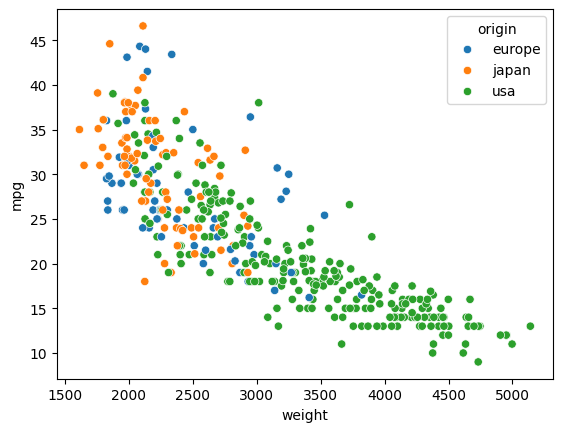

In [7]:
# mpg vs weight vs origin

sns.scatterplot(
    data=df,
    x='weight',
    y='mpg',
    hue='origin',# Generallyy hue is for categorical values
)

plt.show()

# observ: There is more from USA than Japan and Europe
# Cars from USA weigh more than Japan + Europe
# As weight goes up, MPG goes down

# Pairwise Multivariate Relationships (Pairplot)

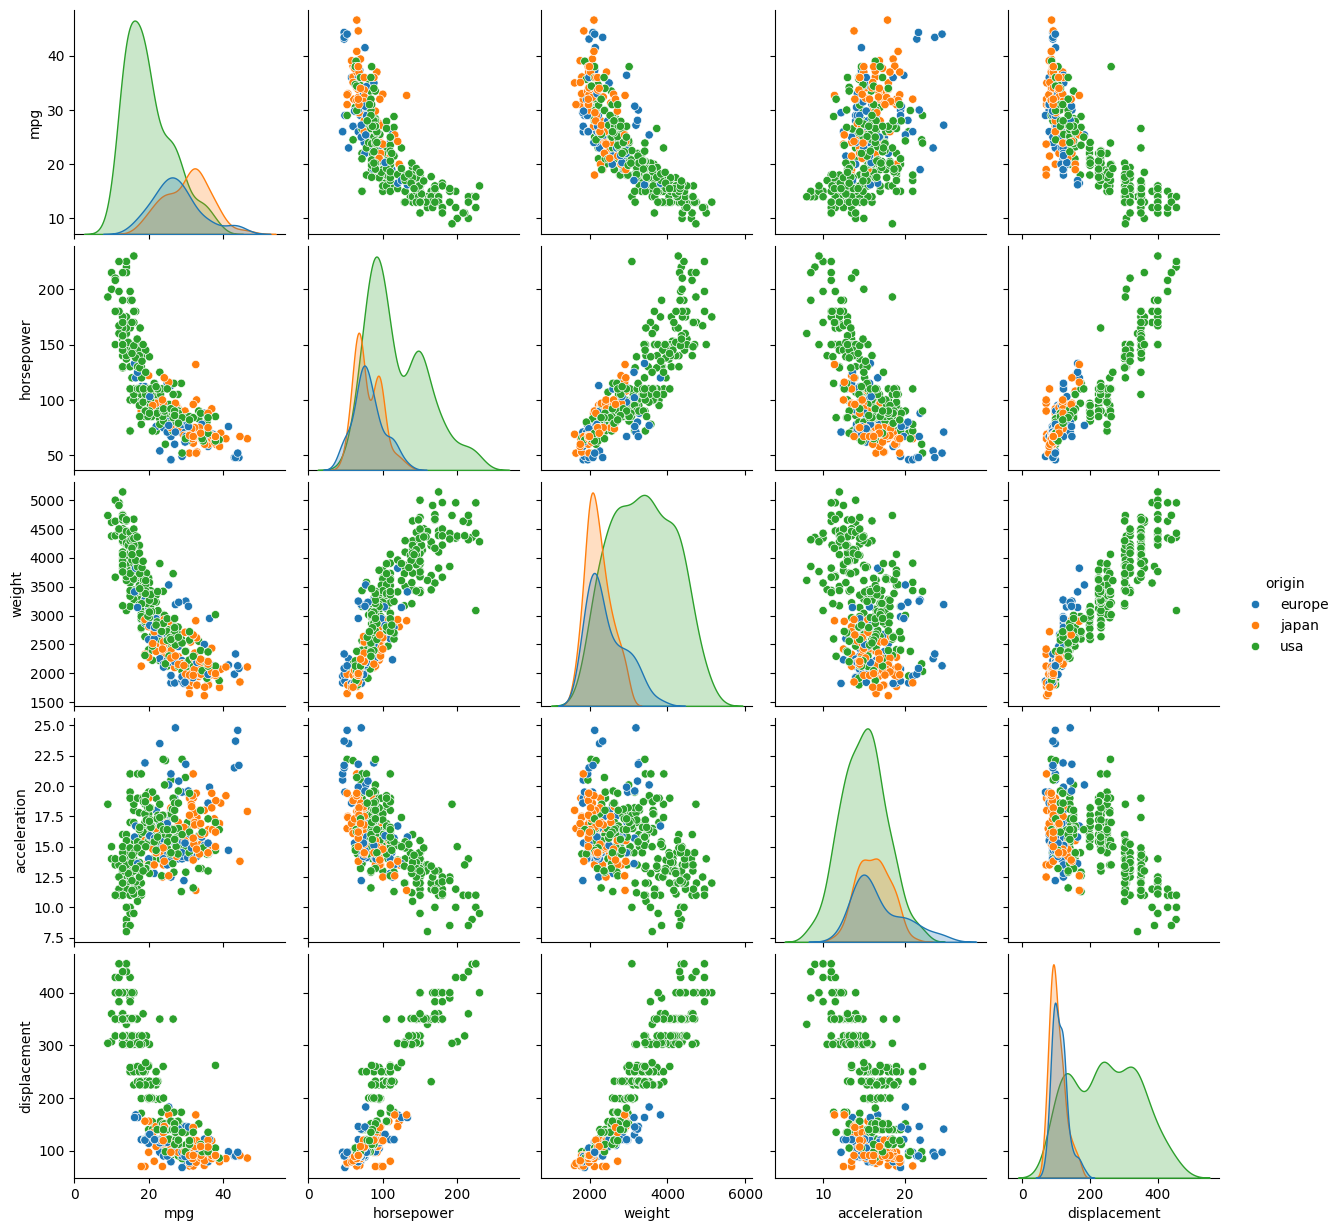

In [9]:
# NOTE: This may take 10 + secods becuase it is plotting 5x5=25 plots
sns.pairplot(
    data=df,
    vars=["mpg", "horsepower", "weight", "acceleration", "displacement"],
    hue="origin",
    diag_kind="kde"
)
plt.show()

# Observ: MPG decreases as weight and horsepower increase
# Cars from different origins cluster differently
# Useful for feature intuition before modeling

# Scatter (3 Variables)

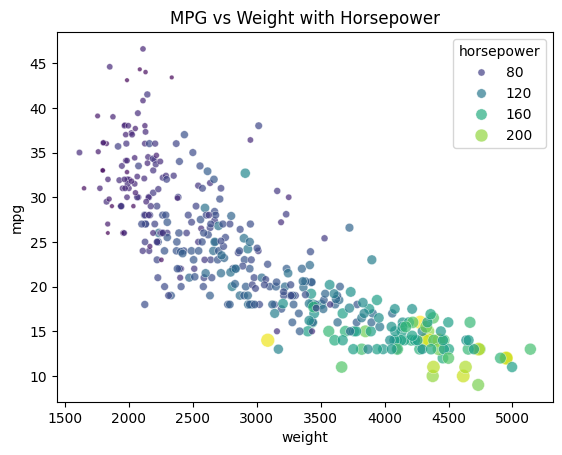

In [12]:
# MPG vs Weight vs Horsepower

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="horsepower",
    size="horsepower",
    palette="viridis",
    # sizes=(20, 200),
    sizes=(10, 100),
    alpha=0.7
)
plt.title("MPG vs Weight with Horsepower")
plt.show()

# Observ: Car with low HP, have less weight and give high MPG

# Categorical + Numerical Multivariate Analysis

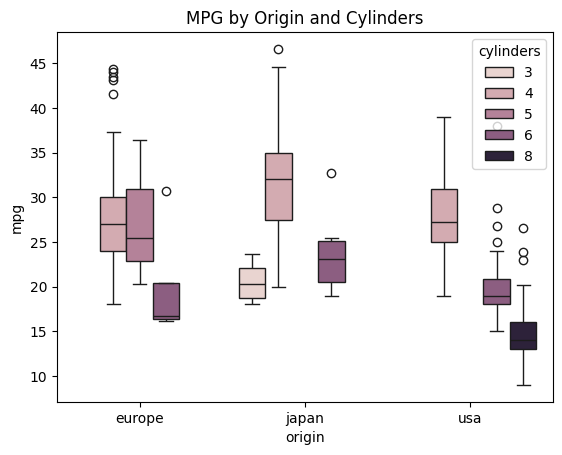

In [14]:
# TODO: Change the color to something more noticable
# MPG by Origin & Cylinders

sns.boxplot(
    data=df,
    x="origin",
    y="mpg",
    hue="cylinders" # It categorical in nature
)
plt.title("MPG by Origin and Cylinders")
plt.show()

# observ: Fewer cylinders → higher MPG

# Faceted Multivariate Analysis (Small Multiples)

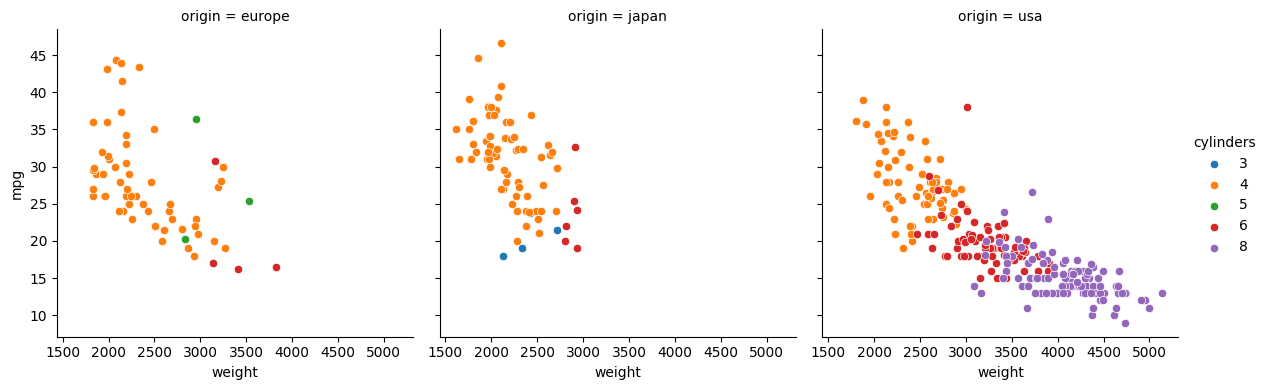

In [16]:
# origin vs cylinders vs weight vs mpg

g = sns.FacetGrid(
    data=df,
    col="origin",
    hue="cylinders",
    height=4,
    aspect=1
)
g.map(sns.scatterplot, "weight", "mpg")
g.add_legend()
plt.show()

# observ: USA does not have 3 clinder or 5 cylinders carts

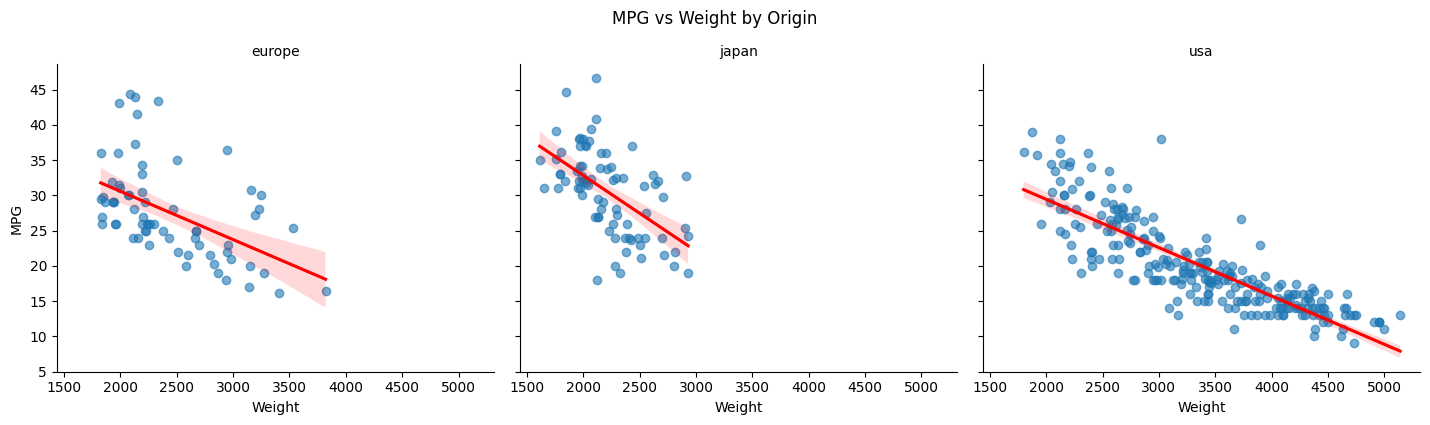

In [18]:
# Linear regression line
g = sns.FacetGrid(
    data=df,
    col="origin",
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map(
    sns.regplot,
    "weight",
    "mpg",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

g.set_axis_labels("Weight", "MPG")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("MPG vs Weight by Origin", y=1.05)

plt.show()
